# Objective

Does the localization improvement have value for automatic license-plate recognition (ALPR)

For every validation image, OCR is applied to three crop sources:

1. **Ground-truth crop**: the annotated plate box; this estimates OCR performance when the detector box is correct.
2. **640 crop**: the highest-confidence prediction from the 640×640 detector.
3. **960 crop**: the highest-confidence prediction from the 960×960 detector.

Hypothesis: If the 960×960 detector produces more precise plate crops, then OCR exact-match accuracy and normalized text similarity should improve relative to the 640×640 detector.

In [1]:
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import os
import re
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytesseract

from pytesseract import Output
from scipy.stats import spearmanr, wilcoxon
from tqdm.auto import tqdm


In [2]:
CURRENT_DIRECTORY = Path.cwd()

PROJECT_ROOT = CURRENT_DIRECTORY.parent

PREDICTION_ANALYSIS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "prediction_analysis.csv"
)

OCR_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ocr_evaluation.csv"
)

REPORT_DIR = PROJECT_ROOT / "reports" / "ocr"
FIGURE_DIR = REPORT_DIR / "figures"
METRICS_OUTPUT_PATH = REPORT_DIR / "ocr_metrics.csv"
TRACK_OUTPUT_PATH = REPORT_DIR / "ocr_track_metrics.csv"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EVALUATION_SPLIT = "validation"
CROP_PADDING_RATIO = 0.05
OCR_TARGET_HEIGHT = 96
TESSERACT_CONFIG = "--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
OCR_CONFIG_ID = "tesseract_psm7_clahe_h96_pad005_v1"

# Set to a small number such as 30 for a quick smoke test.
# Return it to None before reporting metrics.
MAX_IMAGES = None

# Existing results with the same OCR_CONFIG_ID are reused unless this is True.
FORCE_RERUN = False

print("Project root:", PROJECT_ROOT)
print("Prediction table:", PREDICTION_ANALYSIS_PATH)
print("Prediction table exists:", PREDICTION_ANALYSIS_PATH.exists())
print("OCR output:", OCR_OUTPUT_PATH)


Project root: c:\Users\mingj\Desktop\Plate-Recognition
Prediction table: c:\Users\mingj\Desktop\Plate-Recognition\data\processed\prediction_analysis.csv
Prediction table exists: True
OCR output: c:\Users\mingj\Desktop\Plate-Recognition\data\processed\ocr_evaluation.csv


In [3]:
# Install tessereact (https://github.com/UB-Mannheim/tesseract/wiki)
def configure_tesseract() -> Path:
    candidates: List[Path] = []

    environment_path = os.environ.get("TESSERACT_CMD")
    if environment_path:
        candidates.append(Path(environment_path))

    discovered_path = shutil.which("tesseract")
    if discovered_path:
        candidates.append(Path(discovered_path))

    candidates.extend(
        [
            Path("C:/Program Files/Tesseract-OCR/tesseract.exe"),
            Path("C:/Program Files (x86)/Tesseract-OCR/tesseract.exe"),
            Path("/usr/bin/tesseract"),
            Path("/usr/local/bin/tesseract"),
            Path("/opt/homebrew/bin/tesseract"),
        ]
    )

    for candidate in candidates:
        if candidate.exists():
            pytesseract.pytesseract.tesseract_cmd = str(candidate)
            return candidate

    raise FileNotFoundError(
        "Tesseract was not found."
    )


TESSERACT_PATH = configure_tesseract()

print("Tesseract executable:", TESSERACT_PATH)
print("Tesseract version:", pytesseract.get_tesseract_version())


Tesseract executable: C:\Program Files\Tesseract-OCR\tesseract.exe
Tesseract version: 5.5.3.20260724


In [4]:
# Load and validate prediction table
if not PREDICTION_ANALYSIS_PATH.exists():
    raise FileNotFoundError(
        "prediction_analysis.csv was not found. Run 03_analysis.ipynb first."
    )

analysis = pd.read_csv(PREDICTION_ANALYSIS_PATH)

required_columns = {
    "split",
    "track_id",
    "image_name",
    "image_path",
    "plate_text",
    "plate_xmin",
    "plate_ymin",
    "plate_xmax",
    "plate_ymax",
    "detected_640",
    "detected_960",
    "top_confidence_640",
    "top_confidence_960",
    "top_iou_640",
    "top_iou_960",
    "pred_xmin_640",
    "pred_ymin_640",
    "pred_xmax_640",
    "pred_ymax_640",
    "pred_xmin_960",
    "pred_ymin_960",
    "pred_xmax_960",
    "pred_ymax_960",
}

missing_columns = required_columns - set(analysis.columns)
if missing_columns:
    raise KeyError(
        "The prediction table is missing required columns: "
        + str(sorted(missing_columns))
    )

analysis = (
    analysis.loc[analysis["split"] == EVALUATION_SPLIT]
    .copy()
    .sort_values(["track_id", "frame_number", "image_name"])
    .reset_index(drop=True)
)

if MAX_IMAGES is not None:
    analysis = analysis.head(MAX_IMAGES).copy()

analysis["absolute_image_path"] = analysis["image_path"].map(
    lambda value: PROJECT_ROOT / Path(str(value))
)

missing_images = analysis.loc[
    ~analysis["absolute_image_path"].map(Path.exists),
    ["image_name", "absolute_image_path"],
]

print("Images:", len(analysis))
print("Tracks:", analysis["track_id"].nunique())
print("Duplicate image names:", analysis["image_name"].duplicated().sum())
print("Missing image files:", len(missing_images))

if not missing_images.empty:
    display(missing_images.head())
    raise FileNotFoundError("Some source images could not be found.")

analysis[
    [
        "image_name",
        "track_id",
        "plate_text",
        "top_iou_640",
        "top_iou_960",
    ]
].head()


Images: 900
Tracks: 30
Duplicate image names: 0
Missing image files: 0


,image_name,track_id,plate_text,top_iou_640,top_iou_960
0,track0061[01].png,track0061,AYU0035,0.942405,0.878513
1,track0061[02].png,track0061,AYU0035,0.947900,0.898758
2,track0061[03].png,track0061,AYU0035,0.911525,0.867933
3,track0061[04].png,track0061,AYU0035,0.898638,0.857997
4,track0061[05].png,track0061,AYU0035,0.914634,0.841993


# Text metrics

- **Exact match:** the entire normalized OCR prediction equals the seven-character annotation.
- **Edit distance:** minimum number of insertions, deletions, and substitutions needed to transform the prediction into the annotation.
- **Normalized similarity:** `1 − edit_distance / max(true_length, predicted_length)`. A value of 1 is perfect and 0 is maximally different.
- **Character error rate (CER):** `edit_distance / true_length`. Lower is better.
- **Format validity:** prediction matches the dataset pattern of three letters followed by four digits.

In [ ]:
PLATE_PATTERN = re.compile(r"^[A-Z]{3}[0-9]{4}$")


def normalize_plate_text(value: object) -> str:
    """Uppercase text and retain only ASCII letters and digits."""
    return re.sub(r"[^A-Z0-9]", "", str(value).upper())


def levenshtein_distance(text_a: str, text_b: str) -> int:
    """Compute Levenshtein edit distance without an extra dependency."""
    if text_a == text_b:
        return 0

    if not text_a:
        return len(text_b)

    if not text_b:
        return len(text_a)

    previous_row = list(range(len(text_b) + 1))

    for row_index, character_a in enumerate(text_a, start=1):
        current_row = [row_index]

        for column_index, character_b in enumerate(text_b, start=1):
            insertion = current_row[column_index - 1] + 1
            deletion = previous_row[column_index] + 1
            substitution = (
                previous_row[column_index - 1]
                + int(character_a != character_b)
            )

            current_row.append(min(insertion, deletion, substitution))

        previous_row = current_row

    return previous_row[-1]


def calculate_text_metrics(true_text: str, predicted_text: str) -> Dict[str, object]:
    true_normalized = normalize_plate_text(true_text)
    predicted_normalized = normalize_plate_text(predicted_text)

    edit_distance = levenshtein_distance(
        true_normalized,
        predicted_normalized,
    )

    maximum_length = max(
        len(true_normalized),
        len(predicted_normalized),
        1,
    )

    true_length = max(len(true_normalized), 1)

    return {
        "true_plate": true_normalized,
        "predicted_text": predicted_normalized,
        "exact_match": predicted_normalized == true_normalized,
        "edit_distance": edit_distance,
        "normalized_similarity": max(
            0.0,
            1.0 - edit_distance / maximum_length,
        ),
        "character_error_rate": edit_distance / true_length,
        "format_valid": bool(PLATE_PATTERN.fullmatch(predicted_normalized)),
    }


In [ ]:
def clamp_and_pad_box(
    box: Sequence[float],
    image_width: int,
    image_height: int,
    padding_ratio: float,
) -> Optional[Tuple[int, int, int, int]]:
    # Clamp an xyxy box to the image and add proportional padding
    if len(box) != 4 or any(pd.isna(value) for value in box):
        return None

    xmin, ymin, xmax, ymax = [float(value) for value in box]

    if xmax <= xmin or ymax <= ymin:
        return None

    width = xmax - xmin
    height = ymax - ymin

    horizontal_padding = width * padding_ratio
    vertical_padding = height * padding_ratio

    padded_xmin = max(0, int(np.floor(xmin - horizontal_padding)))
    padded_ymin = max(0, int(np.floor(ymin - vertical_padding)))
    padded_xmax = min(
        image_width,
        int(np.ceil(xmax + horizontal_padding)),
    )
    padded_ymax = min(
        image_height,
        int(np.ceil(ymax + vertical_padding)),
    )

    if padded_xmax <= padded_xmin or padded_ymax <= padded_ymin:
        return None

    return padded_xmin, padded_ymin, padded_xmax, padded_ymax


def extract_crop(
    image: np.ndarray,
    box: Sequence[float],
    padding_ratio: float,
) -> Tuple[Optional[np.ndarray], Optional[Tuple[int, int, int, int]]]:
    # Extract one padded plate crop
    image_height, image_width = image.shape[:2]

    final_box = clamp_and_pad_box(
        box=box,
        image_width=image_width,
        image_height=image_height,
        padding_ratio=padding_ratio,
    )

    if final_box is None:
        return None, None

    xmin, ymin, xmax, ymax = final_box
    crop = image[ymin:ymax, xmin:xmax]

    if crop.size == 0:
        return None, final_box

    return crop, final_box


def calculate_crop_features(crop: np.ndarray) -> Dict[str, float]:
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    return {
        "crop_brightness": float(gray.mean()),
        "crop_contrast": float(gray.std()),
        "crop_sharpness": float(
            cv2.Laplacian(gray, cv2.CV_64F).var()
        ),
    }


def preprocess_plate_crop(
    crop: np.ndarray,
    target_height: int,
) -> np.ndarray:
    # Apply one fixed OCR preprocessing pipeline to every crop source
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    scale = max(1.0, target_height / max(gray.shape[0], 1))
    target_width = max(1, int(round(gray.shape[1] * scale)))

    resized = cv2.resize(
        gray,
        (target_width, target_height),
        interpolation=cv2.INTER_CUBIC,
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8),
    )
    enhanced = clahe.apply(resized)

    bordered = cv2.copyMakeBorder(
        enhanced,
        12,
        12,
        12,
        12,
        borderType=cv2.BORDER_CONSTANT,
        value=255,
    )

    return bordered


def run_tesseract(processed_crop: np.ndarray) -> Tuple[str, float]:
    data = pytesseract.image_to_data(
        processed_crop,
        output_type=Output.DICT,
        config=TESSERACT_CONFIG,
    )

    tokens: List[str] = []
    confidence_values: List[float] = []

    for token, confidence in zip(data["text"], data["conf"]):
        normalized_token = normalize_plate_text(token)

        try:
            confidence_float = float(confidence)
        except (TypeError, ValueError):
            confidence_float = -1.0

        if normalized_token:
            tokens.append(normalized_token)

            if confidence_float >= 0:
                confidence_values.append(confidence_float)

    predicted_text = normalize_plate_text("".join(tokens))

    if not predicted_text:
        fallback_text = pytesseract.image_to_string(
            processed_crop,
            config=TESSERACT_CONFIG,
        )
        predicted_text = normalize_plate_text(fallback_text)

    mean_confidence = (
        float(np.mean(confidence_values)) / 100.0
        if confidence_values
        else 0.0
    )

    return predicted_text, mean_confidence


In [ ]:
# Run OCR on all three crop sources
CROP_SOURCES: Dict[str, Dict[str, object]] = {
    "ground_truth": {
        "detected_column": None,
        "confidence_column": None,
        "iou_column": None,
        "box_columns": (
            "plate_xmin",
            "plate_ymin",
            "plate_xmax",
            "plate_ymax",
        ),
    },
    "640": {
        "detected_column": "detected_640",
        "confidence_column": "top_confidence_640",
        "iou_column": "top_iou_640",
        "box_columns": (
            "pred_xmin_640",
            "pred_ymin_640",
            "pred_xmax_640",
            "pred_ymax_640",
        ),
    },
    "960": {
        "detected_column": "detected_960",
        "confidence_column": "top_confidence_960",
        "iou_column": "top_iou_960",
        "box_columns": (
            "pred_xmin_960",
            "pred_ymin_960",
            "pred_xmax_960",
            "pred_ymax_960",
        ),
    },
}


def empty_ocr_record(
    row: pd.Series,
    crop_source: str,
    detector_confidence: float,
    detector_iou: float,
) -> Dict[str, object]:
    text_metrics = calculate_text_metrics(
        true_text=str(row["plate_text"]),
        predicted_text="",
    )

    record: Dict[str, object] = {
        "ocr_config_id": OCR_CONFIG_ID,
        "split": row["split"],
        "track_id": row["track_id"],
        "image_name": row["image_name"],
        "image_path": row["image_path"],
        "crop_source": crop_source,
        "crop_missing": True,
        "detector_confidence": detector_confidence,
        "detector_iou": detector_iou,
        "raw_ocr_text": "",
        "ocr_confidence": 0.0,
        "crop_xmin": np.nan,
        "crop_ymin": np.nan,
        "crop_xmax": np.nan,
        "crop_ymax": np.nan,
        "crop_width": 0,
        "crop_height": 0,
        "crop_brightness": np.nan,
        "crop_contrast": np.nan,
        "crop_sharpness": np.nan,
    }
    record.update(text_metrics)

    return record


def evaluate_crop_source(
    row: pd.Series,
    image: np.ndarray,
    crop_source: str,
) -> Dict[str, object]:
    source_config = CROP_SOURCES[crop_source]

    detected_column = source_config["detected_column"]
    confidence_column = source_config["confidence_column"]
    iou_column = source_config["iou_column"]
    box_columns = source_config["box_columns"]

    if crop_source == "ground_truth":
        detected = True
        detector_confidence = np.nan
        detector_iou = 1.0
    else:
        detected = bool(row[str(detected_column)])
        detector_confidence = float(row[str(confidence_column)])
        detector_iou = float(row[str(iou_column)])

    if not detected:
        return empty_ocr_record(
            row=row,
            crop_source=crop_source,
            detector_confidence=detector_confidence,
            detector_iou=detector_iou,
        )

    box = [float(row[column]) for column in box_columns]

    crop, final_box = extract_crop(
        image=image,
        box=box,
        padding_ratio=CROP_PADDING_RATIO,
    )

    if crop is None or final_box is None:
        return empty_ocr_record(
            row=row,
            crop_source=crop_source,
            detector_confidence=detector_confidence,
            detector_iou=detector_iou,
        )

    processed_crop = preprocess_plate_crop(
        crop=crop,
        target_height=OCR_TARGET_HEIGHT,
    )

    raw_ocr_text, ocr_confidence = run_tesseract(processed_crop)
    text_metrics = calculate_text_metrics(
        true_text=str(row["plate_text"]),
        predicted_text=raw_ocr_text,
    )

    xmin, ymin, xmax, ymax = final_box
    crop_features = calculate_crop_features(crop)

    record = {
        "ocr_config_id": OCR_CONFIG_ID,
        "split": row["split"],
        "track_id": row["track_id"],
        "image_name": row["image_name"],
        "image_path": row["image_path"],
        "crop_source": crop_source,
        "crop_missing": False,
        "detector_confidence": detector_confidence,
        "detector_iou": detector_iou,
        "raw_ocr_text": raw_ocr_text,
        "ocr_confidence": ocr_confidence,
        "crop_xmin": xmin,
        "crop_ymin": ymin,
        "crop_xmax": xmax,
        "crop_ymax": ymax,
        "crop_width": xmax - xmin,
        "crop_height": ymax - ymin,
    }
    record.update(crop_features)
    record.update(text_metrics)

    return record


In [8]:
cached_records = pd.DataFrame()

if OCR_OUTPUT_PATH.exists() and not FORCE_RERUN:
    previous_results = pd.read_csv(OCR_OUTPUT_PATH)

    if "ocr_config_id" in previous_results.columns:
        cached_records = previous_results.loc[
            previous_results["ocr_config_id"] == OCR_CONFIG_ID
        ].copy()

completed_keys = set()

if not cached_records.empty:
    completed_keys = set(
        zip(
            cached_records["image_name"],
            cached_records["crop_source"],
        )
    )

records: List[Dict[str, object]] = cached_records.to_dict(
    orient="records"
)

new_record_count = 0

for _, row in tqdm(
    analysis.iterrows(),
    total=len(analysis),
    desc="Running OCR",
):
    image_path = Path(row["absolute_image_path"])
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError("OpenCV could not read " + str(image_path))

    for crop_source in CROP_SOURCES:
        key = (row["image_name"], crop_source)

        if key in completed_keys:
            continue

        record = evaluate_crop_source(
            row=row,
            image=image,
            crop_source=crop_source,
        )

        records.append(record)
        completed_keys.add(key)
        new_record_count += 1

    # Save periodically so the run can be resumed after interruption.
    if new_record_count > 0 and new_record_count % 150 == 0:
        checkpoint = pd.DataFrame(records).drop_duplicates(
            subset=["ocr_config_id", "image_name", "crop_source"],
            keep="last",
        )
        checkpoint.to_csv(OCR_OUTPUT_PATH, index=False)

ocr_results = pd.DataFrame(records)


Running OCR:   0%|          | 0/900 [00:00<?, ?it/s]

In [9]:
ocr_results = (
    ocr_results
    .drop_duplicates(
        subset=["ocr_config_id", "image_name", "crop_source"],
        keep="last",
    )
    .sort_values(["track_id", "image_name", "crop_source"])
    .reset_index(drop=True)
)

ocr_results.to_csv(OCR_OUTPUT_PATH, index=False)

expected_rows = len(analysis) * len(CROP_SOURCES)

print("OCR rows:", len(ocr_results))
print("Expected rows:", expected_rows)
print("New rows created this run:", new_record_count)
print("Saved to:", OCR_OUTPUT_PATH)

if len(ocr_results) != expected_rows:
    raise ValueError(
        "OCR row count does not match images × crop sources. "
        "Set FORCE_RERUN=True if the cache is incomplete or incompatible."
    )

ocr_results.head()


OCR rows: 2700
Expected rows: 2700
New rows created this run: 2700
Saved to: c:\Users\mingj\Desktop\Plate-Recognition\data\processed\ocr_evaluation.csv


,ocr_config_id,split,track_id,image_name,image_path,crop_source,crop_missing,detector_confidence,detector_iou,raw_ocr_text,...,crop_brightness,crop_contrast,crop_sharpness,true_plate,predicted_text,exact_match,edit_distance,normalized_similarity,character_error_rate,format_valid
0,tesseract_psm7_clahe_h96_pad005_v1,validation,track0061,track0061[01].png,data/raw/ufpr_alpr/validation/track0061/track0...,640,False,0.917480,0.942405,AYU0035,...,192.504876,55.212508,2769.763000,AYU0035,AYU0035,True,0,1.000000,0.000000,True
1,tesseract_psm7_clahe_h96_pad005_v1,validation,track0061,track0061[01].png,data/raw/ufpr_alpr/validation/track0061/track0...,960,False,0.933105,0.878513,AYU0035,...,194.960911,52.125098,4135.475740,AYU0035,AYU0035,True,0,1.000000,0.000000,True
2,tesseract_psm7_clahe_h96_pad005_v1,validation,track0061,track0061[01].png,data/raw/ufpr_alpr/validation/track0061/track0...,ground_truth,False,NaN,1.000000,AYU0035,...,193.882375,54.876828,2823.548128,AYU0035,AYU0035,True,0,1.000000,0.000000,True
3,tesseract_psm7_clahe_h96_pad005_v1,validation,track0061,track0061[02].png,data/raw/ufpr_alpr/validation/track0061/track0...,640,False,0.910156,0.947900,AYU0035,...,193.321429,54.318058,3225.306679,AYU0035,AYU0035,True,0,1.000000,0.000000,True
4,tesseract_psm7_clahe_h96_pad005_v1,validation,track0061,track0061[02].png,data/raw/ufpr_alpr/validation/track0061/track0...,960,False,0.930176,0.898758,AU0035,...,196.012450,50.726642,4490.238135,AYU0035,AU0035,False,1,0.857143,0.142857,False


In [ ]:
# Display overall performance
SOURCE_ORDER = ["ground_truth", "640", "960"]

summary_records: List[Dict[str, object]] = []

for crop_source in SOURCE_ORDER:
    source_frame = ocr_results.loc[
        ocr_results["crop_source"] == crop_source
    ]

    summary_records.append(
        {
            "crop_source": crop_source,
            "images": len(source_frame),
            "crop_available_rate": 1.0 - source_frame["crop_missing"].mean(),
            "exact_match_accuracy": source_frame["exact_match"].mean(),
            "mean_normalized_similarity": source_frame[
                "normalized_similarity"
            ].mean(),
            "mean_edit_distance": source_frame["edit_distance"].mean(),
            "micro_character_error_rate": (
                source_frame["edit_distance"].sum()
                / source_frame["true_plate"].str.len().sum()
            ),
            "format_valid_rate": source_frame["format_valid"].mean(),
            "mean_ocr_confidence": source_frame["ocr_confidence"].mean(),
        }
    )

ocr_summary = pd.DataFrame(summary_records)
ocr_summary.to_csv(METRICS_OUTPUT_PATH, index=False)

ocr_summary

# Remained poor across all crop sources
# 960 detector achieved the highest average character similarity and the lowest character error rate but it produced a lower exact-match accuracy than the 640 detector

,crop_source,images,crop_available_rate,exact_match_accuracy,mean_normalized_similarity,mean_edit_distance,micro_character_error_rate,format_valid_rate,mean_ocr_confidence
0,ground_truth,900,1.000000,0.085556,0.243188,5.306667,0.758095,0.134444,0.015075
1,640,900,0.971111,0.111111,0.246601,5.285556,0.755079,0.157778,0.011933
2,960,900,0.997778,0.082222,0.250190,5.261111,0.751587,0.131111,0.016085


In [ ]:
# Image and tracks are evaluated by both detectors so comparisons are based on pairs
track_metrics = (
    ocr_results
    .groupby(["track_id", "crop_source"], as_index=False)
    .agg(
        images=("image_name", "size"),
        exact_match_rate=("exact_match", "mean"),
        mean_similarity=("normalized_similarity", "mean"),
        mean_edit_distance=("edit_distance", "mean"),
        mean_cer=("character_error_rate", "mean"),
        crop_available_rate=("crop_missing", lambda values: 1.0 - values.mean()),
    )
)

track_metrics.to_csv(TRACK_OUTPUT_PATH, index=False)

exact_match_pivot = track_metrics.pivot(
    index="track_id",
    columns="crop_source",
    values="exact_match_rate",
)

similarity_pivot = track_metrics.pivot(
    index="track_id",
    columns="crop_source",
    values="mean_similarity",
)

paired_track_results = pd.DataFrame(
    {
        "exact_match_640": exact_match_pivot["640"],
        "exact_match_960": exact_match_pivot["960"],
        "similarity_640": similarity_pivot["640"],
        "similarity_960": similarity_pivot["960"],
    }
).dropna()

paired_track_results["exact_match_change"] = (
    paired_track_results["exact_match_960"]
    - paired_track_results["exact_match_640"]
)

paired_track_results["similarity_change"] = (
    paired_track_results["similarity_960"]
    - paired_track_results["similarity_640"]
)

paired_track_results.describe()


,exact_match_640,exact_match_960,similarity_640,similarity_960,exact_match_change,similarity_change
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.111111,0.082222,0.246601,0.250190,-0.028889,0.003589
std,0.203858,0.166950,0.267456,0.282441,0.158473,0.121209
min,0.000000,0.000000,0.000000,0.000000,-0.700000,-0.304762
25%,0.000000,0.000000,0.016667,0.009524,0.000000,-0.059524
50%,0.000000,0.000000,0.147024,0.141964,0.000000,0.000000
75%,0.158333,0.100000,0.436756,0.442560,0.000000,0.029911
max,0.800000,0.733333,0.863095,0.895238,0.233333,0.263690


In [ ]:
# Wilcoxon tests
def safe_one_sided_wilcoxon(
    values_960: pd.Series,
    values_640: pd.Series,
) -> Dict[str, float]:
    """Run a one-sided paired Wilcoxon test when differences are nonzero."""
    differences = (
        values_960.astype(float).to_numpy()
        - values_640.astype(float).to_numpy()
    )

    if np.allclose(differences, 0):
        return {"statistic": np.nan, "p_value": 1.0}

    result = wilcoxon(
        values_960,
        values_640,
        alternative="greater",
    )

    return {
        "statistic": float(result.statistic),
        "p_value": float(result.pvalue),
    }


exact_match_test = safe_one_sided_wilcoxon(
    paired_track_results["exact_match_960"],
    paired_track_results["exact_match_640"],
)

similarity_test = safe_one_sided_wilcoxon(
    paired_track_results["similarity_960"],
    paired_track_results["similarity_640"],
)

print("Track-level exact-match change:", paired_track_results["exact_match_change"].mean())
print("Exact-match Wilcoxon:", exact_match_test)
print()
print("Track-level similarity change:", paired_track_results["similarity_change"].mean())
print("Similarity Wilcoxon:", similarity_test)


Track-level exact-match change: -0.028888888888888895
Exact-match Wilcoxon: {'statistic': 39.5, 'p_value': 0.6627409757496161}

Track-level similarity change: 0.0035890652557319185
Similarity Wilcoxon: {'statistic': 179.0, 'p_value': 0.5949351285481044}


c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


In [ ]:
# Bootstrap confidence intervals
def bootstrap_mean_difference(
    differences: pd.Series,
    repetitions: int = 10000,
    random_state: int = 42,
) -> Tuple[float, float, float]:
    """Bootstrap a 95% confidence interval by resampling tracks."""
    values = differences.dropna().astype(float).to_numpy()
    random_generator = np.random.RandomState(random_state)

    bootstrap_means: List[float] = []

    for _ in range(repetitions):
        sample = random_generator.choice(
            values,
            size=len(values),
            replace=True,
        )
        bootstrap_means.append(float(sample.mean()))

    lower, upper = np.percentile(
        np.asarray(bootstrap_means),
        [2.5, 97.5],
    )

    return float(values.mean()), float(lower), float(upper)


exact_match_ci = bootstrap_mean_difference(
    paired_track_results["exact_match_change"]
)

similarity_ci = bootstrap_mean_difference(
    paired_track_results["similarity_change"]
)

print("Exact-match mean change and 95% CI:", exact_match_ci)
print("Similarity mean change and 95% CI:", similarity_ci)


Exact-match mean change and 95% CI: (-0.028888888888888895, -0.09222222222222222, 0.01888888888888889)
Similarity mean change and 95% CI: (0.0035890652557319185, -0.03844593253968253, 0.046045579805996446)


In [ ]:
# Image level comparisons
image_exact_match = (
    ocr_results.loc[
        ocr_results["crop_source"].isin(["640", "960"]),
        ["image_name", "crop_source", "exact_match"],
    ]
    .pivot(
        index="image_name",
        columns="crop_source",
        values="exact_match",
    )
)

transition_table = pd.DataFrame(
    {
        "outcome": [
            "both correct",
            "640 only correct",
            "960 only correct",
            "both incorrect",
        ],
        "images": [
            int((image_exact_match["640"] & image_exact_match["960"]).sum()),
            int((image_exact_match["640"] & ~image_exact_match["960"]).sum()),
            int((~image_exact_match["640"] & image_exact_match["960"]).sum()),
            int((~image_exact_match["640"] & ~image_exact_match["960"]).sum()),
        ],
    }
)

transition_table


,outcome,images
0,both correct,36
1,640 only correct,64
2,960 only correct,38
3,both incorrect,762


In [ ]:
# Spearman correlation and p value
ocr_640 = (
    ocr_results.loc[
        ocr_results["crop_source"] == "640",
        [
            "image_name",
            "track_id",
            "predicted_text",
            "exact_match",
            "normalized_similarity",
        ],
    ]
    .rename(
        columns={
            "predicted_text": "predicted_text_640",
            "exact_match": "exact_match_640",
            "normalized_similarity": "similarity_640",
        }
    )
)

ocr_960 = (
    ocr_results.loc[
        ocr_results["crop_source"] == "960",
        [
            "image_name",
            "predicted_text",
            "exact_match",
            "normalized_similarity",
        ],
    ]
    .rename(
        columns={
            "predicted_text": "predicted_text_960",
            "exact_match": "exact_match_960",
            "normalized_similarity": "similarity_960",
        }
    )
)

translation_analysis = (
    analysis[
        [
            "image_name",
            "plate_text",
            "top_iou_640",
            "top_iou_960",
        ]
    ]
    .merge(ocr_640, on="image_name", how="inner", validate="one_to_one")
    .merge(ocr_960, on="image_name", how="inner", validate="one_to_one")
)

translation_analysis["iou_change"] = (
    translation_analysis["top_iou_960"]
    - translation_analysis["top_iou_640"]
)

translation_analysis["ocr_similarity_change"] = (
    translation_analysis["similarity_960"]
    - translation_analysis["similarity_640"]
)

translation_analysis["ocr_exact_match_change"] = (
    translation_analysis["exact_match_960"].astype(int)
    - translation_analysis["exact_match_640"].astype(int)
)

track_translation = (
    translation_analysis
    .groupby("track_id", as_index=False)
    .agg(
        mean_iou_change=("iou_change", "mean"),
        mean_ocr_similarity_change=("ocr_similarity_change", "mean"),
        mean_exact_match_change=("ocr_exact_match_change", "mean"),
    )
)

translation_correlation, translation_p_value = spearmanr(
    track_translation["mean_iou_change"],
    track_translation["mean_ocr_similarity_change"],
)

print("Track-level Spearman correlation:", translation_correlation)
print("p-value:", translation_p_value)

track_translation.head()

# No relationship between improvements in localization quality and OCR performance
# Vehicle tracks that had larger IoU gains did not consistently achieve better OCR similarity or exact-match accuracy


Track-level Spearman correlation: 0.0008903729814906762
p-value: 0.9962742582214984


,track_id,mean_iou_change,mean_ocr_similarity_change,mean_exact_match_change
0,track0061,0.040599,0.032143,0.066667
1,track0062,0.041306,-0.083333,-0.100000
2,track0063,0.044010,0.263690,0.233333
3,track0064,0.026303,-0.061905,-0.033333
4,track0065,0.020071,0.153902,0.100000


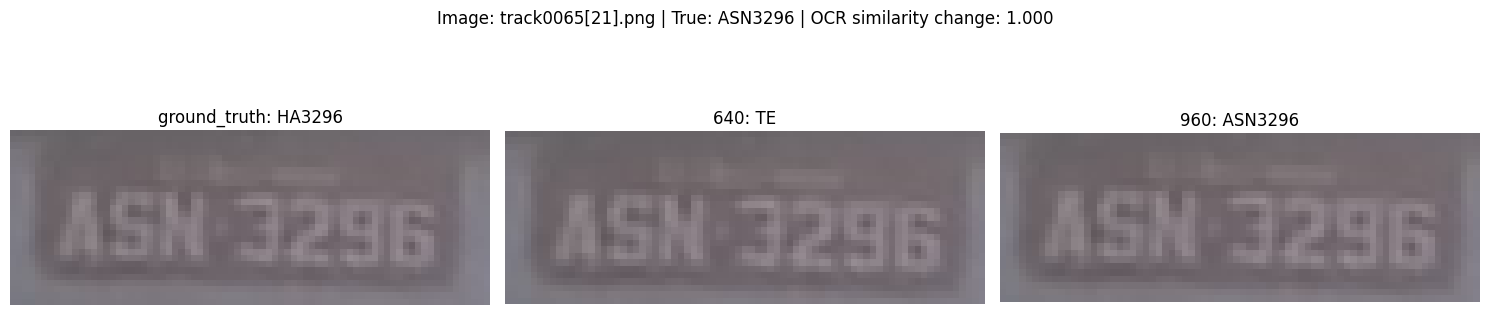

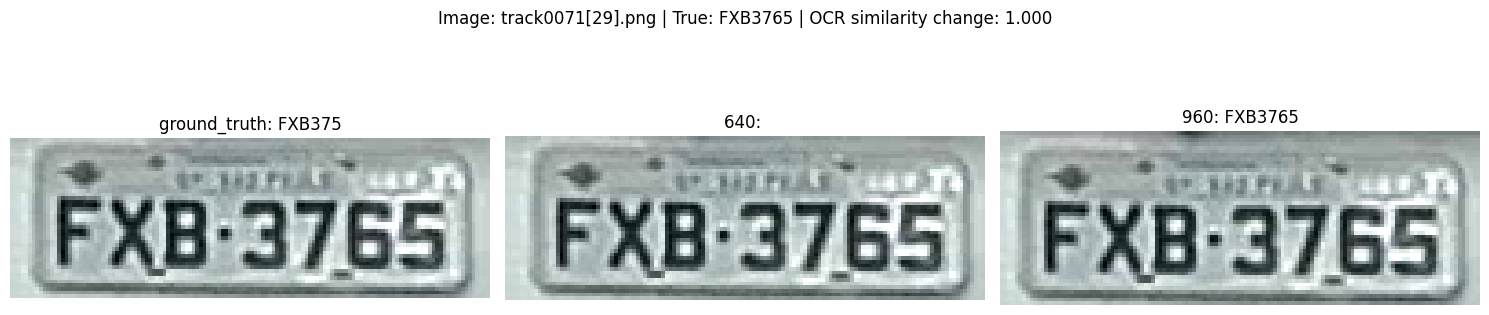

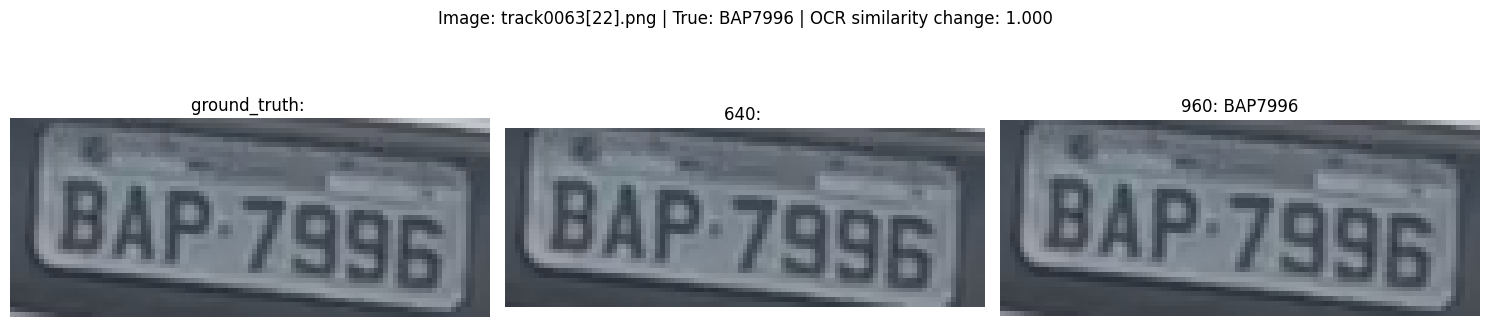

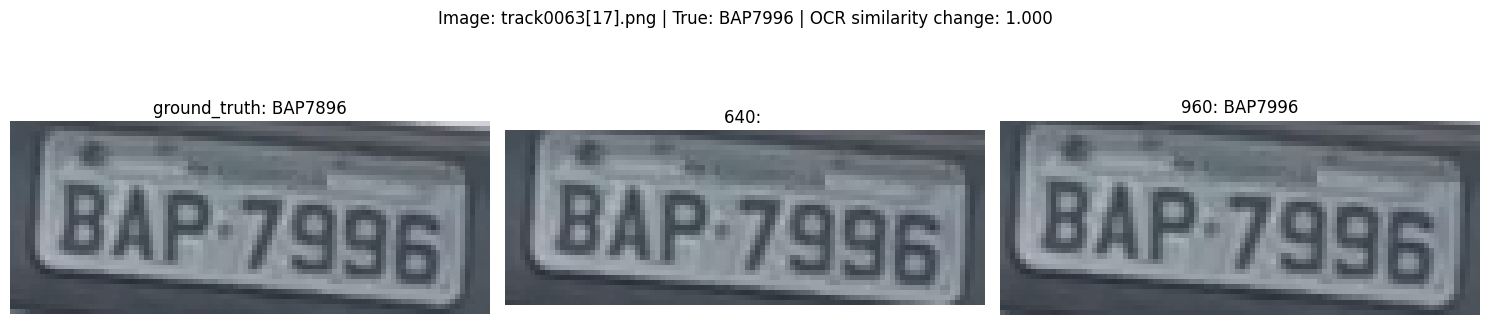

In [ ]:
# Crops with the largest OCR similarity changes
def get_source_box(
    row: pd.Series,
    crop_source: str,
) -> Optional[List[float]]:
    """Read a crop box from the merged analysis row."""
    source_config = CROP_SOURCES[crop_source]
    box_columns = source_config["box_columns"]

    values = [row[column] for column in box_columns]

    if any(pd.isna(value) for value in values):
        return None

    return [float(value) for value in values]


def display_comparison_examples(
    number_of_examples: int = 4,
    show_largest_improvements: bool = True,
) -> None:
    """Display OCR crops with the largest positive or negative changes."""
    ordered = translation_analysis.sort_values(
        "ocr_similarity_change",
        ascending=not show_largest_improvements,
    ).head(number_of_examples)

    for _, comparison_row in ordered.iterrows():
        source_row = analysis.loc[
            analysis["image_name"] == comparison_row["image_name"]
        ].iloc[0]

        image = cv2.imread(str(source_row["absolute_image_path"]))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        figure, axes = plt.subplots(1, 3, figsize=(15, 4))

        for axis, crop_source in zip(axes, SOURCE_ORDER):
            box = get_source_box(source_row, crop_source)

            if box is None:
                axis.text(0.5, 0.5, "No crop", ha="center", va="center")
                axis.axis("off")
                continue

            crop, _ = extract_crop(
                image=image,
                box=box,
                padding_ratio=CROP_PADDING_RATIO,
            )

            if crop is None:
                axis.text(0.5, 0.5, "No crop", ha="center", va="center")
                axis.axis("off")
                continue

            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            axis.imshow(crop_rgb)

            prediction = ocr_results.loc[
                (ocr_results["image_name"] == comparison_row["image_name"])
                & (ocr_results["crop_source"] == crop_source),
                "predicted_text",
            ].iloc[0]

            axis.set_title(crop_source + ": " + str(prediction))
            axis.axis("off")

        figure.suptitle(
            "Image: "
            + comparison_row["image_name"]
            + " | True: "
            + normalize_plate_text(comparison_row["plate_text"])
            + " | OCR similarity change: "
            + f"{comparison_row['ocr_similarity_change']:.3f}"
        )
        plt.tight_layout()
        plt.show()


# Largest improvements from 640 to 960
display_comparison_examples(
    number_of_examples=4,
    show_largest_improvements=True,
)

# Higher-resolution localization occasionally produce tighter bounding boxes and improved character recognition
# However, some examples showed little or no OCR improvement despite better localization

# Conclusion

Increasing the detector input resolution improved localization quality and reduced the number of missing crops but these improvements did not produce a statistically significant improvement in OCR performance. Furthermore, there is no correlation between IoU improvement and OCR improvement which indicates that better localization alone does not guarantee better recognition. Overall, the results suggest that OCR performance is limited primarily by the recognition stage rather than the localization stage and future improvements are therefore more likely to come from stronger OCR models or enhanced image preprocessing than from further increases in detector resolution.